# Moving Average, FIR, and IIR Filter Utilities
Reusable Python code snippets for core digital filtering in sonar and general DSP.

---

## 1. Moving Average Filter
### Theory
A simple smoothing filter that replaces each point in the signal with the average of its neighbors within a window.

**Use cases:** Denoising, smoothing, baseline removal.


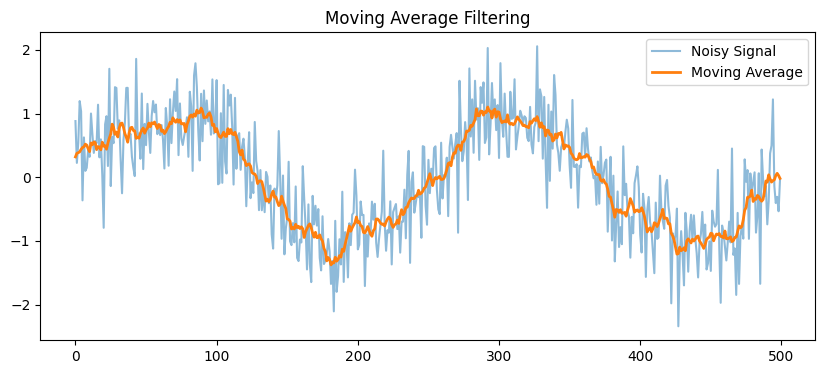

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def moving_average(signal, window_size=5):
    """Simple moving average filter."""
    return np.convolve(signal, np.ones(window_size)/window_size, mode='same')

# Demo with noise
np.random.seed(0)
signal = np.sin(2*np.pi*2*np.linspace(0,1,500)) + 0.5*np.random.randn(500)
filtered = moving_average(signal, window_size=11)

plt.figure(figsize=(10,4))
plt.plot(signal, alpha=0.5, label='Noisy Signal')
plt.plot(filtered, label='Moving Average', linewidth=2)
plt.title('Moving Average Filtering')
plt.legend(); plt.show()


## 2. FIR Bandpass Filter
### Theory
Finite Impulse Response (FIR) filters use a finite number of past inputs to filter a signal. They're stable and have a linear phase.

**Use cases:** Bandpass, lowpass, and highpass filtering.



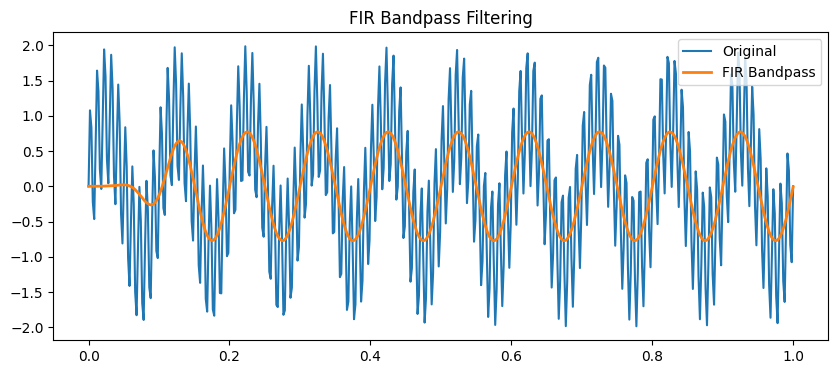

In [2]:
from scipy.signal import firwin, lfilter

def fir_bandpass(signal, fs, lowcut, highcut, numtaps=101):
    """FIR bandpass filter."""
    taps = firwin(numtaps, [lowcut, highcut], pass_zero=False, fs=fs)
    return lfilter(taps, 1.0, signal)

# Demo: isolate low-frequency sine in noisy signal
fs = 500  # Hz
t = np.linspace(0, 1.0, fs)
signal = np.sin(2*np.pi*10*t) + np.sin(2*np.pi*100*t)
filtered = fir_bandpass(signal, fs, lowcut=8, highcut=20)

plt.figure(figsize=(10,4))
plt.plot(t, signal, label='Original')
plt.plot(t, filtered, label='FIR Bandpass', linewidth=2)
plt.title('FIR Bandpass Filtering')
plt.legend(); plt.show()


## 3. IIR Lowpass Filter (Butterworth)
### Theory
Infinite Impulse Response (IIR) filters use both past inputs and outputs, mimicking analog filters. Efficient for sharp cutoffs.

**Use cases:** Real-time filtering, envelope detection.



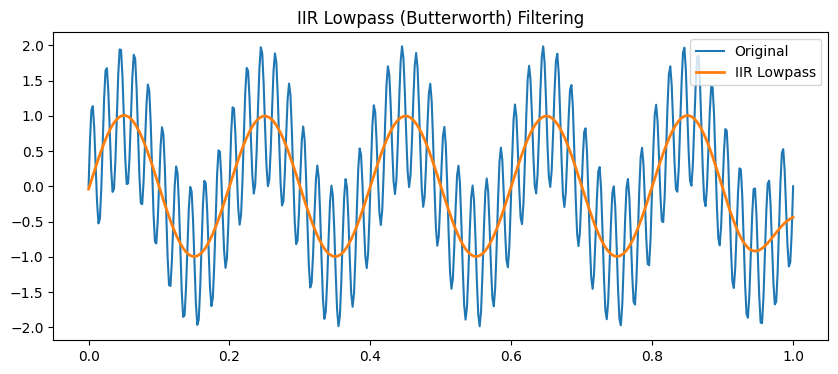

In [3]:
from scipy.signal import butter, filtfilt

def iir_lowpass(signal, fs, cutoff=10, order=4):
    """IIR lowpass Butterworth filter."""
    b, a = butter(order, cutoff/(0.5*fs), btype='low')
    return filtfilt(b, a, signal)

# Demo: lowpass filter to isolate low-frequency content
fs = 500
t = np.linspace(0, 1.0, fs)
signal = np.sin(2*np.pi*5*t) + np.sin(2*np.pi*50*t)
filtered = iir_lowpass(signal, fs, cutoff=10)

plt.figure(figsize=(10,4))
plt.plot(t, signal, label='Original')
plt.plot(t, filtered, label='IIR Lowpass', linewidth=2)
plt.title('IIR Lowpass (Butterworth) Filtering')
plt.legend(); plt.show()
